In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
drive.flush_and_unmount()
drive.mount('/content/drive')
!ls /content/drive/MyDrive/ | grep -i sub1

Mounted at /content/drive
sub1_comp.mat
sub1_testlabels.mat


In [3]:
!cp /content/drive/MyDrive/sub1_comp.mat .
!cp /content/drive/MyDrive/sub1_testlabels.mat .
!ls -lh sub1_*.mat

-rw------- 1 root root 134M May 15 03:32 sub1_comp.mat
-rw------- 1 root root 6.8M May 15 03:32 sub1_testlabels.mat


In [4]:
import numpy as np
from xgboost import XGBClassifier

# X = 特征
# 每一行代表一个学生：
# [学习时间, 睡眠时间, 是否复习]
X = np.array([
    [1, 5, 0],
    [2, 6, 0],
    [3, 6, 1],
    [4, 7, 1],
    [5, 7, 1],
    [6, 8, 1],
    [1, 4, 0],
    [2, 5, 0],
])

# y = 标签
# 0 = 没通过，1 = 通过
y = np.array([
    0,
    0,
    1,
    1,
    1,
    1,
    0,
    0,
])

# 创建 XGBoost 分类模型
model = XGBClassifier(
    n_estimators=11,      # 使用10棵树
    max_depth=2,          # 每棵树最多2层，防止太复杂
    learning_rate=0.1,    # 每次修正不要太猛
    random_state=42
)

# 训练模型
model.fit(X, y)

# 预测一个新学生
# 学习4小时，睡眠7小时，复习了
new_student = np.array([[4, 7, 1]])

prediction = model.predict(new_student)

print("预测结果:", prediction[0])

if prediction[0] == 1:
    print("这个学生可能会通过考试")
else:
    print("这个学生可能不会通过考试")

预测结果: 1
这个学生可能会通过考试


train_dg shape: (400000, 5)
test_dg shape: (200000, 5)
train_dg_smooth shape: (400000, 5)
test_dg_smooth shape: (200000, 5)


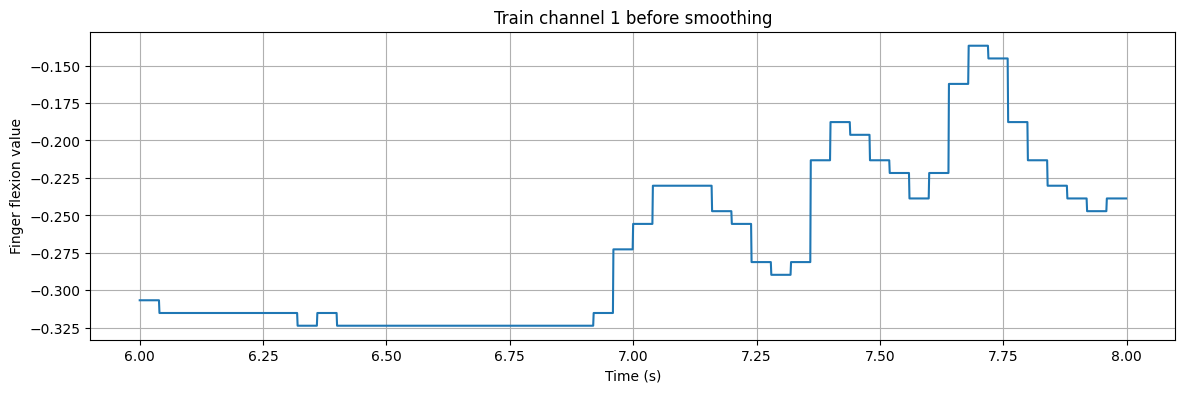

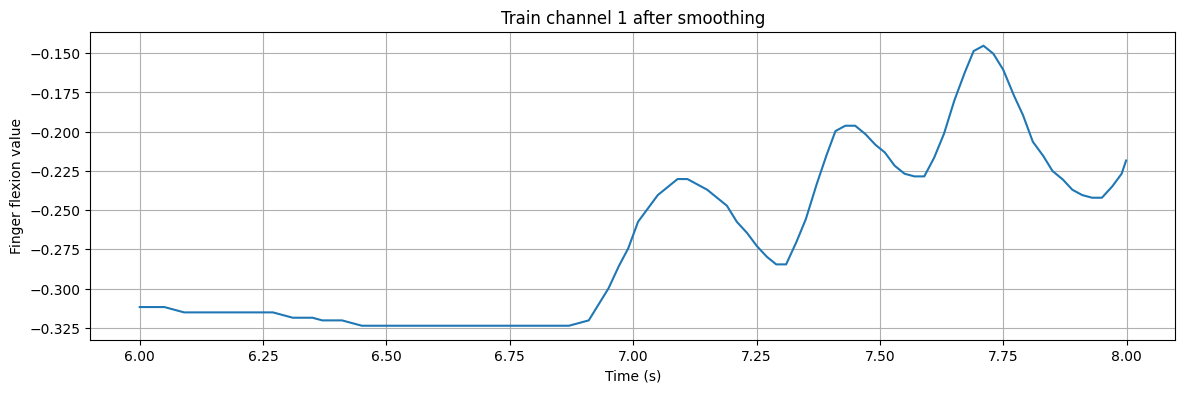

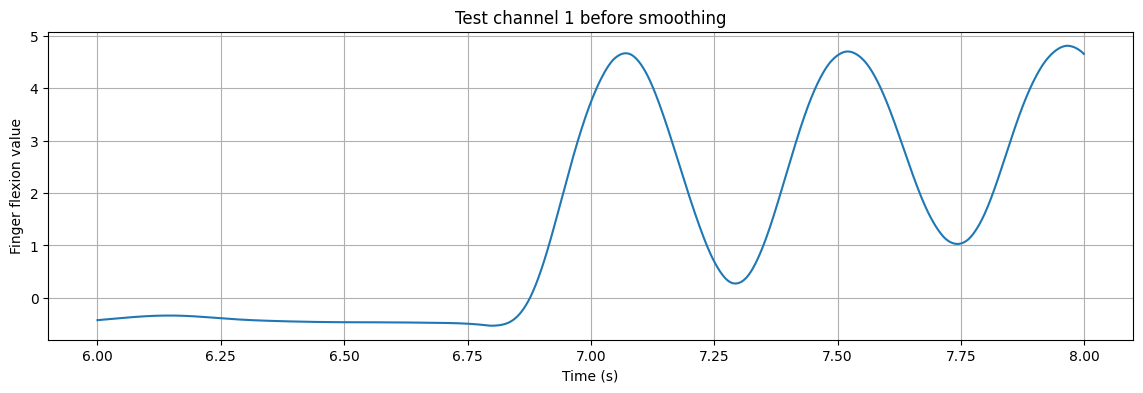

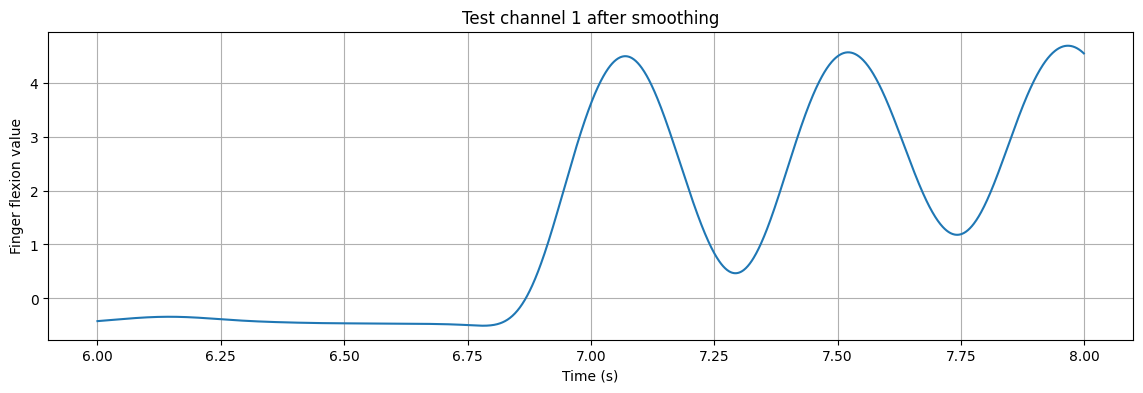

In [5]:
#1. 做平滑处理
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Load data
# =========================

train_mat = loadmat("sub1_comp.mat")
test_label_mat = loadmat("sub1_testlabels.mat")

train_dg = train_mat["train_dg"]      # shape: (400000, 5)
test_dg = test_label_mat["test_dg"]   # shape: (200000, 5)

print("train_dg shape:", train_dg.shape)
print("test_dg shape:", test_dg.shape)

# =========================
# 2. Smooth all 5 channels
# =========================

def moving_average_smooth_all_channels(data, window_size=100):
    """
    对所有 channel/手指分别做 moving average smoothing

    data shape:
        (time, channels)

    window_size:
        100 samples = 100 ms，因为采样率是 1000 Hz
    """
    smoothed = np.zeros_like(data)
    kernel = np.ones(window_size) / window_size

    for ch in range(data.shape[1]):
        smoothed[:, ch] = np.convolve(data[:, ch], kernel, mode="same")

    return smoothed


window_size = 100   # 100 ms smoothing window

train_dg_smooth = moving_average_smooth_all_channels(train_dg, window_size)
test_dg_smooth = moving_average_smooth_all_channels(test_dg, window_size)

print("train_dg_smooth shape:", train_dg_smooth.shape)
print("test_dg_smooth shape:", test_dg_smooth.shape)

# =========================
# 3. Select channel 1 only for plotting
# =========================

channel_index = 0   # channel 1 = 第 1 列 = thumb

fs = 1000           # sampling rate = 1000 Hz
start_sec = 6       # 从第 0 秒开始
duration_sec = 2    # 展示 5 秒

start = start_sec * fs
end = start + duration_sec * fs

time_axis = np.arange(start, end) / fs

# =========================
# 4. Plot train channel 1 before smoothing
# =========================

plt.figure(figsize=(14, 4))
plt.plot(time_axis, train_dg[start:end, channel_index])
plt.xlabel("Time (s)")
plt.ylabel("Finger flexion value")
plt.title("Train channel 1 before smoothing")
plt.grid(True)
plt.show()

# =========================
# 5. Plot train channel 1 after smoothing
# =========================

plt.figure(figsize=(14, 4))
plt.plot(time_axis, train_dg_smooth[start:end, channel_index])
plt.xlabel("Time (s)")
plt.ylabel("Finger flexion value")
plt.title("Train channel 1 after smoothing")
plt.grid(True)

plt.show()

# =========================
# 6. Plot test channel 1 before smoothing
# =========================

plt.figure(figsize=(14, 4))
plt.plot(time_axis, test_dg[start:end, channel_index])
plt.xlabel("Time (s)")
plt.ylabel("Finger flexion value")
plt.title("Test channel 1 before smoothing")
plt.grid(True)
plt.show()

# =========================
# 7. Plot test channel 1 after smoothing
# =========================

plt.figure(figsize=(14, 4))
plt.plot(time_axis, test_dg_smooth[start:end, channel_index])
plt.xlabel("Time (s)")
plt.ylabel("Finger flexion value")
plt.title("Test channel 1 after smoothing")
plt.grid(True)
plt.show()

In [6]:
#算阈值
import numpy as np
import pandas as pd

# =========================
# 1. Define alpha
# =========================

alpha = 0.25

finger_names = ["thumb", "index", "middle", "ring", "little"]

# =========================
# 2. Choose data
# =========================
# 推荐：用平滑后的 train_dg
data = train_dg_smooth

# 如果你没有 train_dg_smooth，就用原始 train_dg：
# data = train_dg

# =========================
# 3. Calculate threshold for each finger
# =========================

thresholds = {}

for i, finger in enumerate(finger_names):
    finger_signal = data[:, i]

    min_val = np.min(finger_signal)
    max_val = np.max(finger_signal)

    ROM = max_val - min_val
    threshold = alpha * ROM

    thresholds[finger] = threshold

# =========================
# 4. Print thresholds
# =========================

print("Thresholds for each finger:")
for finger, threshold in thresholds.items():
    print(f"{finger}: {threshold:.4f}")

Thresholds for each finger:
thumb: 1.5841
index: 1.9700
middle: 2.0511
ring: 1.6346
little: 1.7277


In [7]:
from scipy.io import loadmat
import numpy as np
import pandas as pd

# =========================
# 1. Load data
# =========================

train_mat = loadmat("sub1_comp.mat")
test_label_mat = loadmat("sub1_testlabels.mat")

train_dg = train_mat["train_dg"]       # shape: (400000, 5)
test_dg = test_label_mat["test_dg"]    # shape: (200000, 5)

finger_names = ["thumb", "index", "middle", "ring", "little"]


# 手指编码
finger_code_map = {
    "thumb": 0,
    "index": 1,
    "middle": 2,
    "ring": 3,
    "little": 3
}

print("train_dg shape:", train_dg.shape)
print("test_dg shape:", test_dg.shape)


# =========================
# 2. Smooth all 5 fingers
# =========================

def moving_average_smooth_all_channels(data, window_size=100):
    """
    对所有手指分别做滑动平均平滑
    window_size = 100 means 100 ms because fs = 1000 Hz
    """
    smoothed = np.zeros_like(data)
    kernel = np.ones(window_size) / window_size

    for ch in range(data.shape[1]):
        smoothed[:, ch] = np.convolve(data[:, ch], kernel, mode="same")

    return smoothed


smooth_window_size = 100

train_dg_smooth = moving_average_smooth_all_channels(train_dg, smooth_window_size)
test_dg_smooth = moving_average_smooth_all_channels(test_dg, smooth_window_size)


# =========================
# 3. Calculate thresholds from train_dg_smooth
# =========================

alpha = 0.25

thresholds = {}

for i, finger in enumerate(finger_names):
    finger_signal = train_dg_smooth[:, i]

    min_val = np.min(finger_signal)
    max_val = np.max(finger_signal)

    ROM = max_val - min_val
    threshold = alpha * ROM

    thresholds[finger] = threshold

threshold_df = pd.DataFrame({
    "finger": finger_names,
    "threshold": [thresholds[f] for f in finger_names]
})

display(threshold_df)


# =========================
# 4. Define window classification rule
# =========================

def classify_one_window_one_finger(window_signal, threshold):
    """
    对一个窗口内的一个手指信号进行分类。

    规则：
    1. 如果 max - min < threshold:
          静止 -> 0

    2. 如果 max - min >= threshold:
          计算 slope
          如果 positive slope 数量 > negative slope 数量:
              开 -> 2
          否则:
              合 -> 1
    """

    window_range = np.max(window_signal) - np.min(window_signal)

    if window_range < threshold:
        action_code = 0      # still
    else:
        slopes = np.diff(window_signal)

        positive_count = np.sum(slopes > 0)
        negative_count = np.sum(slopes < 0)

        if positive_count > negative_count:
            action_code = 2  # open
        else:
            action_code = 1  # close

    return action_code, window_range


# =========================
# 5. Encode all windows
# =========================

def encode_windows(data, thresholds, fs=1000, window_sec=0.25):
    """
    对整个 train_dg 或 test_dg 进行窗口编码。

    data shape:
        (time, 5)

    return:
        每个 window，每个手指都有一个编码结果
    """

    window_size = int(fs * window_sec)
    num_windows = data.shape[0] // window_size

    results = []

    for w in range(num_windows):
        start = w * window_size
        end = start + window_size

        window_data = data[start:end, :]

        for i, finger in enumerate(finger_names):
            window_signal = window_data[:, i]
            threshold = thresholds[finger]

            action_code, window_range = classify_one_window_one_finger(
                window_signal,
                threshold
            )

            finger_code = finger_code_map[finger]

            # 两位编码：第一位是手指，第二位是动作
            final_code = f"{finger_code}{action_code}"

            results.append({
                "window_id": w,
                "start_sample": start,
                "end_sample": end,
                "start_time_sec": start / fs,
                "end_time_sec": end / fs,
                "finger": finger,
                "finger_code": finger_code,
                "action_code": action_code,
                "final_code": final_code,
                "window_range": window_range,
                "threshold": threshold
            })

    return pd.DataFrame(results)


# =========================
# 6. Apply to train and test
# =========================

train_encoded_df = encode_windows(
    data=train_dg_smooth,
    thresholds=thresholds,
    fs=1000,
    window_sec=0.25
)

test_encoded_df = encode_windows(
    data=test_dg_smooth,
    thresholds=thresholds,
    fs=1000,
    window_sec=0.25
)

start_sec = 6
end_sec = 8

train_encoded_3_13 = train_encoded_df[
    (train_encoded_df["start_time_sec"] >= start_sec) &
    (train_encoded_df["end_time_sec"] <= end_sec)
]

test_encoded_3_13 = test_encoded_df[
    (test_encoded_df["start_time_sec"] >= start_sec) &
    (test_encoded_df["end_time_sec"] <= end_sec)
]

print("Train encoded result from 3s to 13s:")
display(train_encoded_3_13)

print("Test encoded result from 3s to 13s:")
display(test_encoded_3_13)

train_dg shape: (400000, 5)
test_dg shape: (200000, 5)


,finger,threshold
0,thumb,1.584075
1,index,1.970036
2,middle,2.051125
3,ring,1.634646
4,little,1.727712


Train encoded result from 3s to 13s:


,window_id,start_sample,end_sample,start_time_sec,end_time_sec,finger,finger_code,action_code,final_code,window_range,threshold
120,24,6000,6250,6.00,6.25,thumb,0,0,00,0.003398,1.584075
121,24,6000,6250,6.00,6.25,index,1,0,10,0.142189,1.970036
122,24,6000,6250,6.00,6.25,middle,2,0,20,0.054891,2.051125
123,24,6000,6250,6.00,6.25,ring,3,0,30,0.023951,1.634646
124,24,6000,6250,6.00,6.25,little,3,0,30,0.007253,1.727712
125,25,6250,6500,6.25,6.50,thumb,0,0,00,0.008496,1.584075
126,25,6250,6500,6.25,6.50,index,1,0,10,0.138500,1.970036
127,25,6250,6500,6.25,6.50,middle,2,0,20,0.031439,2.051125
128,25,6250,6500,6.25,6.50,ring,3,0,30,0.089576,1.634646
129,25,6250,6500,6.25,6.50,little,3,0,30,0.010395,1.727712


Test encoded result from 3s to 13s:


,window_id,start_sample,end_sample,start_time_sec,end_time_sec,finger,finger_code,action_code,final_code,window_range,threshold
120,24,6000,6250,6.00,6.25,thumb,0,0,00,0.080743,1.584075
121,24,6000,6250,6.00,6.25,index,1,0,10,0.078837,1.970036
122,24,6000,6250,6.00,6.25,middle,2,0,20,0.411986,2.051125
123,24,6000,6250,6.00,6.25,ring,3,2,32,2.095878,1.634646
124,24,6000,6250,6.00,6.25,little,3,0,30,0.195485,1.727712
125,25,6250,6500,6.25,6.50,thumb,0,0,00,0.076036,1.584075
126,25,6250,6500,6.25,6.50,index,1,0,10,0.083169,1.970036
127,25,6250,6500,6.25,6.50,middle,2,0,20,0.293234,2.051125
128,25,6250,6500,6.25,6.50,ring,3,1,31,2.183636,1.634646
129,25,6250,6500,6.25,6.50,little,3,0,30,0.115830,1.727712


Thresholds:
thumb: 1.5841
index: 1.9700
middle: 2.0511
ring: 1.6346
little: 1.7277


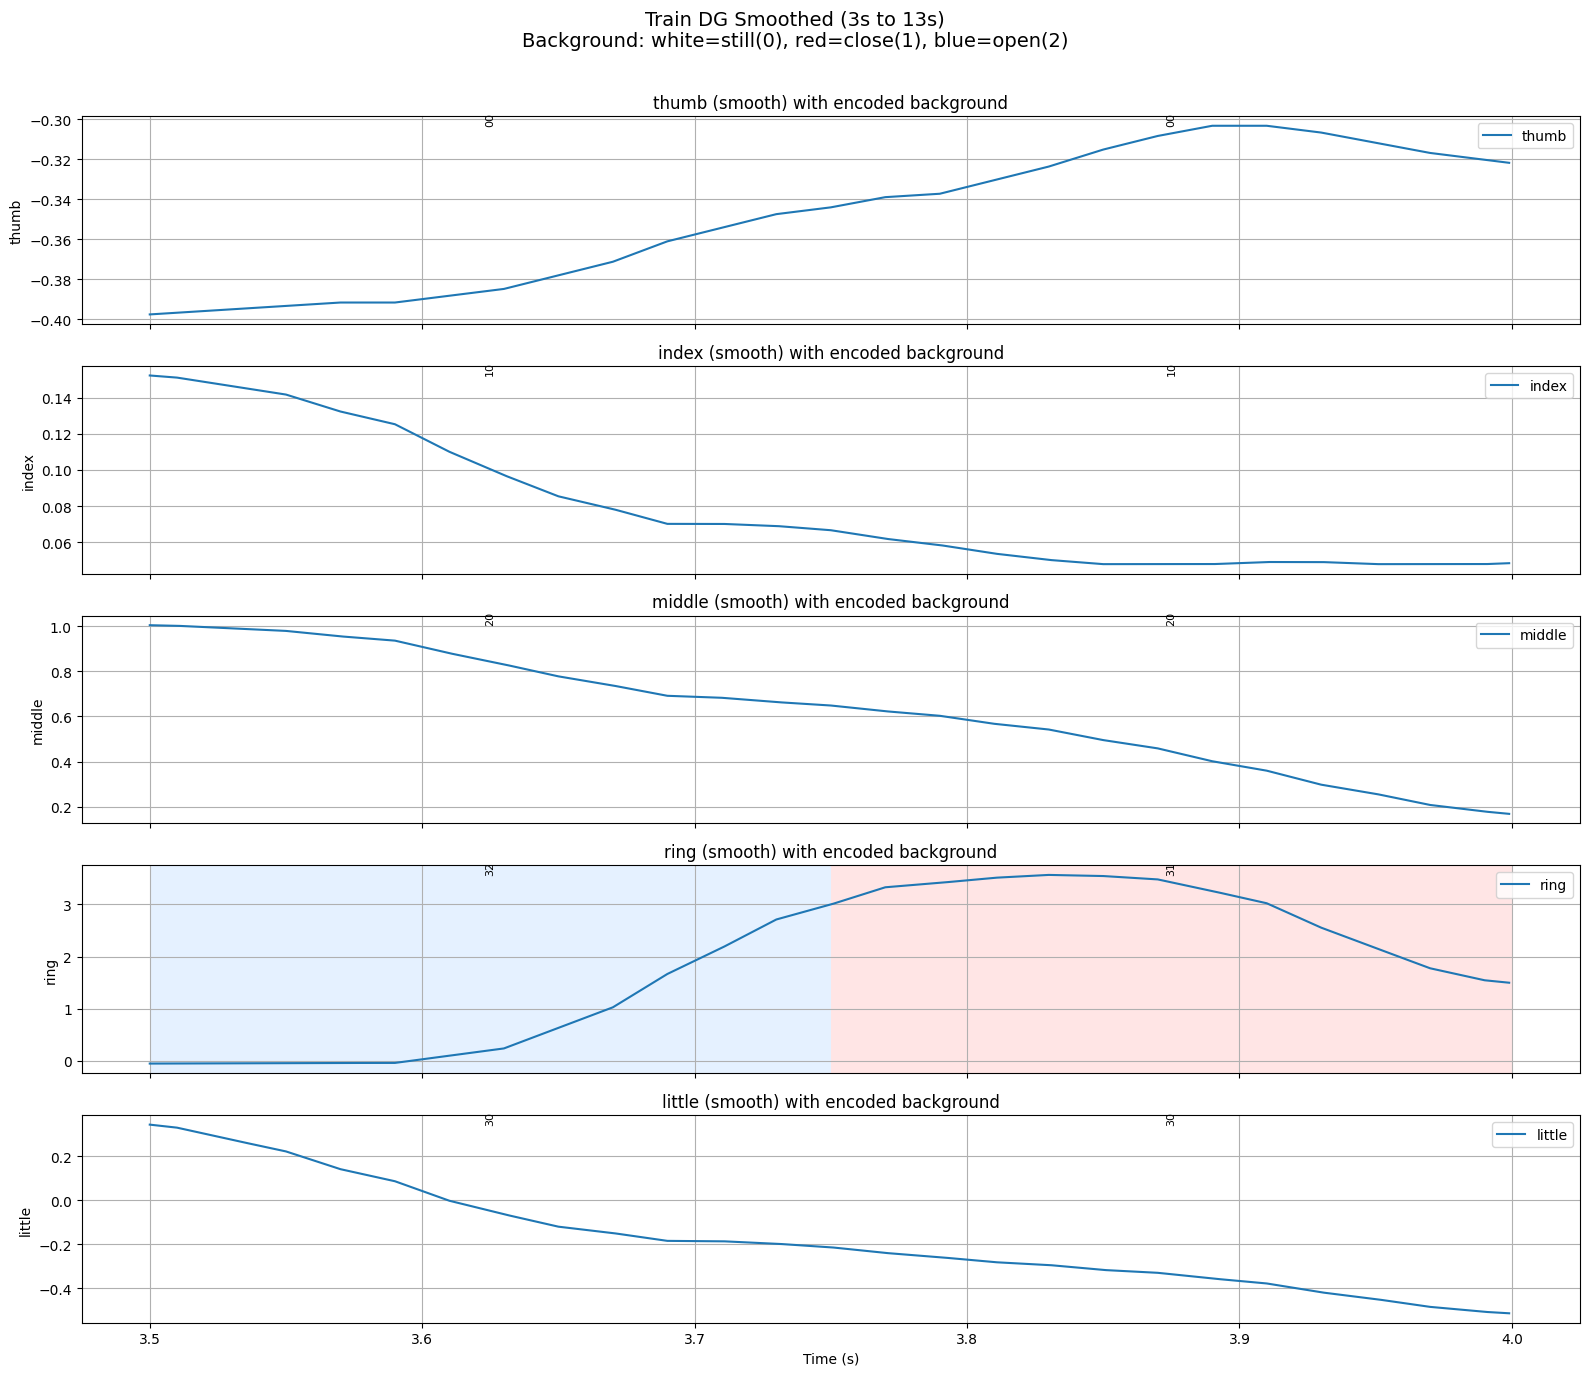

In [8]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Load data
# =========================
mat = loadmat("sub1_comp.mat")
train_dg = mat["train_dg"]   # shape: (400000, 5)

finger_names = ["thumb", "index", "middle", "ring", "little"]

# 手指编号（用于显示编码）
finger_code_map = {
    "thumb": 0,
    "index": 1,
    "middle": 2,
    "ring": 3,
    "little": 3   # 无名指和小拇指合并
}

# =========================
# 2. Smooth all 5 channels
# =========================
def moving_average_smooth_all_channels(data, window_size=100):
    smoothed = np.zeros_like(data)
    kernel = np.ones(window_size) / window_size
    for ch in range(data.shape[1]):
        smoothed[:, ch] = np.convolve(data[:, ch], kernel, mode="same")
    return smoothed

smooth_window_size = 100   # 100 samples = 100 ms
train_dg_smooth = moving_average_smooth_all_channels(train_dg, smooth_window_size)

# =========================
# 3. Compute thresholds from smoothed train_dg
# =========================
alpha = 0.25
thresholds = {}

for i, finger in enumerate(finger_names):
    signal = train_dg_smooth[:, i]
    ROM = np.max(signal) - np.min(signal)
    thresholds[finger] = alpha * ROM

print("Thresholds:")
for finger in finger_names:
    print(f"{finger}: {thresholds[finger]:.4f}")

# =========================
# 4. Window classification
# Rule:
#   max-min < threshold -> still (0)
#   else:
#       positive slopes > negative slopes -> open (2)
#       otherwise -> close (1)
# =========================
def classify_one_window_one_finger(window_signal, threshold):
    window_range = np.max(window_signal) - np.min(window_signal)

    if window_range < threshold:
        action_code = 0   # still
    else:
        slopes = np.diff(window_signal)
        positive_count = np.sum(slopes > 0)
        negative_count = np.sum(slopes < 0)

        if positive_count > negative_count:
            action_code = 2   # open
        else:
            action_code = 1   # close

    return action_code, window_range

# =========================
# 5. Encode all windows
# =========================
fs = 1000
window_sec = 0.25
window_size = int(fs * window_sec)
num_windows = train_dg_smooth.shape[0] // window_size

encoded_results = []

for w in range(num_windows):
    start = w * window_size
    end = start + window_size

    for i, finger in enumerate(finger_names):
        window_signal = train_dg_smooth[start:end, i]
        action_code, window_range = classify_one_window_one_finger(
            window_signal,
            thresholds[finger]
        )

        finger_code = finger_code_map[finger]
        final_code = f"{finger_code}{action_code}"

        encoded_results.append({
            "window_id": w,
            "finger": finger,
            "finger_index": i,
            "start_sample": start,
            "end_sample": end,
            "start_time_sec": start / fs,
            "end_time_sec": end / fs,
            "action_code": action_code,
            "final_code": final_code,
            "window_range": window_range,
            "threshold": thresholds[finger]
        })

# =========================
# 6. Plot 3s to 13s with background colors
# white = still (0)
# red   = close (1)
# blue  = open (2)
# =========================
start_sec = 14/4
end_sec = 16/4

start_sample = int(start_sec * fs)
end_sample = int(end_sec * fs)
time_axis = np.arange(start_sample, end_sample) / fs

color_map = {
    0: "white",      # still
    1: "#ffcccc",    # close -> light red
    2: "#cce5ff"     # open  -> light blue
}

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

for i, finger in enumerate(finger_names):
    ax = axes[i]

    # 先画背景色（按每个 window 的编码）
    for row in encoded_results:
        if row["finger"] != finger:
            continue

        ws = row["start_time_sec"]
        we = row["end_time_sec"]

        # 只画 3s~13s 范围内的 window
        if we <= start_sec or ws >= end_sec:
            continue

        bg_color = color_map[row["action_code"]]
        ax.axvspan(max(ws, start_sec), min(we, end_sec),
                   color=bg_color, alpha=0.5, linewidth=0)

        # 在每个 window 顶部标 final_code，方便检查
        x_center = (max(ws, start_sec) + min(we, end_sec)) / 2
        y_top = np.max(train_dg_smooth[start_sample:end_sample, i])
        ax.text(x_center, y_top, row["final_code"],
                ha="center", va="bottom", fontsize=8, color="black", rotation=90)

    # 再画 smooth 后曲线
    ax.plot(
        time_axis,
        train_dg_smooth[start_sample:end_sample, i],
        linewidth=1.5,
        label=f"{finger}"
    )

    ax.set_ylabel(finger)
    ax.set_title(f"{finger} (smooth) with encoded background")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s)")
plt.suptitle("Train DG Smoothed (3s to 13s)\nBackground: white=still(0), red=close(1), blue=open(2)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [9]:
#重新变成0~8的编码
# =========================
# 1. Create one label per window
# =========================

label_map = {
    ("thumb", 1): 1,
    ("thumb", 2): 2,

    ("index", 1): 3,
    ("index", 2): 4,

    ("middle", 1): 5,
    ("middle", 2): 6,

    ("ring", 1): 7,
    ("ring", 2): 8,

    ("little", 1): 7,
    ("little", 2): 8,
}

label_name_map = {
    0: "no_movement",
    1: "thumb_close",
    2: "thumb_open",
    3: "index_close",
    4: "index_open",
    5: "middle_close",
    6: "middle_open",
    7: "ring_little_close",
    8: "ring_little_open"
}


def make_window_labels(encoded_df):
    """
    把每个 window 里的 5 个手指结果合并成一个最终 label。

    规则：
    1. 如果 5 个手指 action_code 都是 0，则 label = 0
    2. 如果有一个或多个手指 action_code != 0，
       选择 normalized_change = window_range / threshold 最大的那个手指
    """

    labels = []

    for window_id, group in encoded_df.groupby("window_id"):
        group = group.copy()

        # 只看非静止的手指
        moving = group[group["action_code"] != 0].copy()

        if len(moving) == 0:
            final_label = 0
        else:
            # 计算标准化变化强度
            moving["normalized_change"] = moving["window_range"] / moving["threshold"]

            # 选变化最明显的手指
            best_row = moving.loc[moving["normalized_change"].idxmax()]

            finger = best_row["finger"]
            action_code = int(best_row["action_code"])

            final_label = label_map[(finger, action_code)]

        labels.append({
            "window_id": window_id,
            "label": final_label,
            "label_name": label_name_map[final_label]
        })

    return pd.DataFrame(labels)


train_window_labels = make_window_labels(train_encoded_df)
test_window_labels = make_window_labels(test_encoded_df)

print("Train labels:")
display(train_window_labels.head())

print("Test labels:")
display(test_window_labels.head())

print("Train label counts:")
display(train_window_labels["label_name"].value_counts())

print("Test label counts:")
display(test_window_labels["label_name"].value_counts())

Train labels:


,window_id,label,label_name
0,0,0,no_movement
1,1,0,no_movement
2,2,0,no_movement
3,3,0,no_movement
4,4,0,no_movement


Test labels:


,window_id,label,label_name
0,0,0,no_movement
1,1,6,middle_open
2,2,6,middle_open
3,3,5,middle_close
4,4,0,no_movement


Train label counts:


,count
label_name,
no_movement,580
ring_little_close,206
ring_little_open,189
middle_close,117
middle_open,109
index_open,109
thumb_close,100
index_close,98
thumb_open,92


Test label counts:


,count
label_name,
no_movement,364
ring_little_close,95
ring_little_open,90
thumb_open,71
thumb_close,69
index_open,34
index_close,30
middle_close,24
middle_open,23


In [10]:
from scipy.io import loadmat

# 读取官方原始数据
mat = loadmat("sub1_comp.mat")

train_data = mat["train_data"]   # X_train 原始输入
train_dg = mat["train_dg"]       # y_train 原始标签
test_data = mat["test_data"]     # X_test 原始输入

# 读取后来下载的官方测试标签
test_label_mat = loadmat("sub1_testlabels.mat")

test_dg = test_label_mat["test_dg"]   # y_test 原始标签

print("train_data:", train_data.shape)
print("train_dg:", train_dg.shape)
print("test_data:", test_data.shape)
print("test_dg:", test_dg.shape)

train_data: (400000, 62)
train_dg: (400000, 5)
test_data: (200000, 62)
test_dg: (200000, 5)


In [11]:
print("train_encoded_df shape:", train_encoded_df.shape)
print("test_encoded_df shape:", test_encoded_df.shape)

display(train_encoded_df.head(10))
display(test_encoded_df.head(10))

train_encoded_df shape: (8000, 11)
test_encoded_df shape: (4000, 11)


,window_id,start_sample,end_sample,start_time_sec,end_time_sec,finger,finger_code,action_code,final_code,window_range,threshold
0,0,0,250,0.00,0.25,thumb,0,0,00,0.200056,1.584075
1,0,0,250,0.00,0.25,index,1,0,10,0.088395,1.970036
2,0,0,250,0.00,0.25,middle,2,0,20,0.499782,2.051125
3,0,0,250,0.00,0.25,ring,3,0,30,0.029125,1.634646
4,0,0,250,0.00,0.25,little,3,0,30,0.209820,1.727712
5,1,250,500,0.25,0.50,thumb,0,0,00,0.000000,1.584075
6,1,250,500,0.25,0.50,index,1,0,10,0.004685,1.970036
7,1,250,500,0.25,0.50,middle,2,0,20,0.006338,2.051125
8,1,250,500,0.25,0.50,ring,3,0,30,0.002395,1.634646
9,1,250,500,0.25,0.50,little,3,0,30,0.000000,1.727712


,window_id,start_sample,end_sample,start_time_sec,end_time_sec,finger,finger_code,action_code,final_code,window_range,threshold
0,0,0,250,0.00,0.25,thumb,0,0,00,0.353505,1.584075
1,0,0,250,0.00,0.25,index,1,0,10,0.211675,1.970036
2,0,0,250,0.00,0.25,middle,2,0,20,1.448005,2.051125
3,0,0,250,0.00,0.25,ring,3,0,30,0.122969,1.634646
4,0,0,250,0.00,0.25,little,3,0,30,0.064408,1.727712
5,1,250,500,0.25,0.50,thumb,0,0,00,0.044335,1.584075
6,1,250,500,0.25,0.50,index,1,0,10,0.137763,1.970036
7,1,250,500,0.25,0.50,middle,2,2,22,2.227618,2.051125
8,1,250,500,0.25,0.50,ring,3,0,30,0.168620,1.634646
9,1,250,500,0.25,0.50,little,3,0,30,0.080590,1.727712


In [12]:
import numpy as np
import pandas as pd

# =========================
# 1. Final label definition
# =========================

label_map = {
    ("thumb", 1): 1,
    ("thumb", 2): 2,

    ("index", 1): 3,
    ("index", 2): 4,

    ("middle", 1): 5,
    ("middle", 2): 6,

    ("ring", 1): 7,
    ("ring", 2): 8,

    ("little", 1): 7,
    ("little", 2): 8,
}

label_name_map = {
    0: "no_movement",
    1: "thumb_close",
    2: "thumb_open",
    3: "index_close",
    4: "index_open",
    5: "middle_close",
    6: "middle_open",
    7: "ring_little_close",
    8: "ring_little_open"
}

# =========================
# 2. Merge 5 finger rows into 1 label per window
# =========================

def make_window_labels(encoded_df):
    labels = []

    for window_id, group in encoded_df.groupby("window_id"):
        group = group.copy()

        moving = group[group["action_code"] != 0].copy()

        if len(moving) == 0:
            final_label = 0
        else:
            moving["normalized_change"] = moving["window_range"] / moving["threshold"]
            best_row = moving.loc[moving["normalized_change"].idxmax()]

            finger = best_row["finger"]
            action_code = int(best_row["action_code"])

            final_label = label_map[(finger, action_code)]

        labels.append({
            "window_id": window_id,
            "label": final_label,
            "label_name": label_name_map[final_label]
        })

    return pd.DataFrame(labels)

train_window_labels = make_window_labels(train_encoded_df)
test_window_labels = make_window_labels(test_encoded_df)

print("train_window_labels shape:", train_window_labels.shape)
print("test_window_labels shape:", test_window_labels.shape)

display(train_window_labels.head(20))
display(test_window_labels.head(20))

print("Train label distribution:")
display(train_window_labels["label_name"].value_counts())

print("Test label distribution:")
display(test_window_labels["label_name"].value_counts())

train_window_labels shape: (1600, 3)
test_window_labels shape: (800, 3)


,window_id,label,label_name
0,0,0,no_movement
1,1,0,no_movement
2,2,0,no_movement
3,3,0,no_movement
4,4,0,no_movement
5,5,0,no_movement
6,6,0,no_movement
7,7,0,no_movement
8,8,0,no_movement
9,9,0,no_movement


,window_id,label,label_name
0,0,0,no_movement
1,1,6,middle_open
2,2,6,middle_open
3,3,5,middle_close
4,4,0,no_movement
5,5,0,no_movement
6,6,0,no_movement
7,7,0,no_movement
8,8,0,no_movement
9,9,0,no_movement


Train label distribution:


,count
label_name,
no_movement,580
ring_little_close,206
ring_little_open,189
middle_close,117
middle_open,109
index_open,109
thumb_close,100
index_close,98
thumb_open,92


Test label distribution:


,count
label_name,
no_movement,364
ring_little_close,95
ring_little_open,90
thumb_open,71
thumb_close,69
index_open,34
index_close,30
middle_close,24
middle_open,23


In [13]:
#开始训练！！！！
# =========================
# 0. Import packages
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [14]:
# =========================
# 1. Load ECoG input data
# =========================

mat = loadmat("sub1_comp.mat")

train_data = mat["train_data"]   # ECoG train input, shape: (400000, 62)
test_data = mat["test_data"]     # ECoG test input, shape: (200000, 62)

print("train_data shape:", train_data.shape)
print("test_data shape:", test_data.shape)


train_data shape: (400000, 62)
test_data shape: (200000, 62)


In [15]:
# =========================
# 2. Prepare labels
# =========================

y_train_all = train_window_labels["label"].values
y_test_all = test_window_labels["label"].values

print("y_train_all shape:", y_train_all.shape)
print("y_test_all shape:", y_test_all.shape)

print("Train label distribution:")
display(train_window_labels["label_name"].value_counts())

print("Test label distribution:")
display(test_window_labels["label_name"].value_counts())

y_train_all shape: (1600,)
y_test_all shape: (800,)
Train label distribution:


,count
label_name,
no_movement,580
ring_little_close,206
ring_little_open,189
middle_close,117
middle_open,109
index_open,109
thumb_close,100
index_close,98
thumb_open,92


Test label distribution:


,count
label_name,
no_movement,364
ring_little_close,95
ring_little_open,90
thumb_open,71
thumb_close,69
index_open,34
index_close,30
middle_close,24
middle_open,23


In [16]:
# =========================
# 3. Extract features from each 0.25s ECoG window
# =========================

def extract_features_from_windows(ecog_data, fs=1000, window_sec=0.25):
    """
    ecog_data shape:
        time × channels

    Each 0.25s window:
        250 samples × 62 channels

    For each channel, extract:
        mean, std, min, max, range, rms, energy, slope_mean, slope_std

    Output:
        X shape = num_windows × num_features
    """

    window_size = int(fs * window_sec)
    num_windows = ecog_data.shape[0] // window_size

    feature_rows = []

    for w in range(num_windows):
        start = w * window_size
        end = start + window_size

        window = ecog_data[start:end, :]   # shape: 250 × channels

        features = []

        for ch in range(window.shape[1]):
            signal = window[:, ch]

            mean_val = np.mean(signal)
            std_val = np.std(signal)
            min_val = np.min(signal)
            max_val = np.max(signal)
            range_val = max_val - min_val
            rms_val = np.sqrt(np.mean(signal ** 2))
            energy_val = np.sum(signal ** 2)

            slopes = np.diff(signal)
            slope_mean = np.mean(slopes)
            slope_std = np.std(slopes)

            features.extend([
                mean_val,
                std_val,
                min_val,
                max_val,
                range_val,
                rms_val,
                energy_val,
                slope_mean,
                slope_std
            ])

        feature_rows.append(features)

    X = np.array(feature_rows)

    return X


X_train_all = extract_features_from_windows(train_data, fs=1000, window_sec=0.25)
X_test_all = extract_features_from_windows(test_data, fs=1000, window_sec=0.25)

print("X_train_all shape:", X_train_all.shape)
print("X_test_all shape:", X_test_all.shape)
print("y_train_all shape:", y_train_all.shape)
print("y_test_all shape:", y_test_all.shape)

/tmp/ipykernel_11056/1398593383.py:41: RuntimeWarning: invalid value encountered in sqrt
  rms_val = np.sqrt(np.mean(signal ** 2))
/tmp/ipykernel_11056/1398593383.py:40: RuntimeWarning: overflow encountered in scalar subtract
  range_val = max_val - min_val


X_train_all shape: (1600, 558)
X_test_all shape: (800, 558)
y_train_all shape: (1600,)
y_test_all shape: (800,)


In [17]:
# =========================
# 4. Time-based train / validation split
# =========================

split_ratio = 0.8
split_idx = int(len(X_train_all) * split_ratio)

X_train = X_train_all[:split_idx]
y_train = y_train_all[:split_idx]

X_val = X_train_all[split_idx:]
y_val = y_train_all[split_idx:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Val labels:", np.unique(y_val, return_counts=True))

X_train shape: (1280, 558)
y_train shape: (1280,)
X_val shape: (320, 558)
y_val shape: (320,)
Train labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([477,  77,  69,  80,  90,  99,  90, 157, 141]))
Val labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([103,  23,  23,  18,  19,  18,  19,  49,  48]))


In [18]:
# =========================
# 5. Standardize features
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_all)

print("Feature scaling done.")

Feature scaling done.


In [19]:
# =========================
# 6. Train XGBoost model
# =========================

num_classes = 9

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",

    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    tree_method="hist"
)

xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=True
)

[0]	validation_0-mlogloss:1.89488	validation_1-mlogloss:1.97273
[1]	validation_0-mlogloss:1.85643	validation_1-mlogloss:1.95691
[2]	validation_0-mlogloss:1.81672	validation_1-mlogloss:1.93795
[3]	validation_0-mlogloss:1.77926	validation_1-mlogloss:1.92148
[4]	validation_0-mlogloss:1.74749	validation_1-mlogloss:1.90748
[5]	validation_0-mlogloss:1.71197	validation_1-mlogloss:1.88799
[6]	validation_0-mlogloss:1.67950	validation_1-mlogloss:1.87260
[7]	validation_0-mlogloss:1.64918	validation_1-mlogloss:1.85870
[8]	validation_0-mlogloss:1.61915	validation_1-mlogloss:1.84774
[9]	validation_0-mlogloss:1.58937	validation_1-mlogloss:1.83337
[10]	validation_0-mlogloss:1.56134	validation_1-mlogloss:1.82022
[11]	validation_0-mlogloss:1.53576	validation_1-mlogloss:1.80591
[12]	validation_0-mlogloss:1.51004	validation_1-mlogloss:1.79087
[13]	validation_0-mlogloss:1.48688	validation_1-mlogloss:1.78016
[14]	validation_0-mlogloss:1.46356	validation_1-mlogloss:1.77020
[15]	validation_0-mlogloss:1.44170	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=9, ...)

In [20]:
# =========================
# 7. Validation evaluation
# =========================

label_name_map = {
    0: "no_movement",
    1: "thumb_close",
    2: "thumb_open",
    3: "index_close",
    4: "index_open",
    5: "middle_close",
    6: "middle_open",
    7: "ring_little_close",
    8: "ring_little_open"
}

y_val_pred = xgb_model.predict(X_val_scaled)

val_acc = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_acc)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        labels=list(range(num_classes)),
        target_names=[label_name_map[i] for i in range(num_classes)],
        zero_division=0
    )
)

val_cm = confusion_matrix(y_val, y_val_pred, labels=list(range(num_classes)))

print("\nValidation Confusion Matrix:")
print(val_cm)

Validation Accuracy: 0.459375

Validation Classification Report:
                   precision    recall  f1-score   support

      no_movement       0.46      0.89      0.61       103
      thumb_close       0.42      0.22      0.29        23
       thumb_open       0.25      0.13      0.17        23
      index_close       0.50      0.17      0.25        18
       index_open       0.64      0.37      0.47        19
     middle_close       0.43      0.17      0.24        18
      middle_open       0.40      0.11      0.17        19
ring_little_close       0.44      0.33      0.38        49
 ring_little_open       0.53      0.33      0.41        48

         accuracy                           0.46       320
        macro avg       0.45      0.30      0.33       320
     weighted avg       0.46      0.46      0.41       320


Validation Confusion Matrix:
[[92  0  0  0  3  0  0  5  3]
 [10  5  8  0  0  0  0  0  0]
 [14  6  3  0  0  0  0  0  0]
 [12  1  0  3  1  1  0  0  0]
 [ 8  0  0  2  

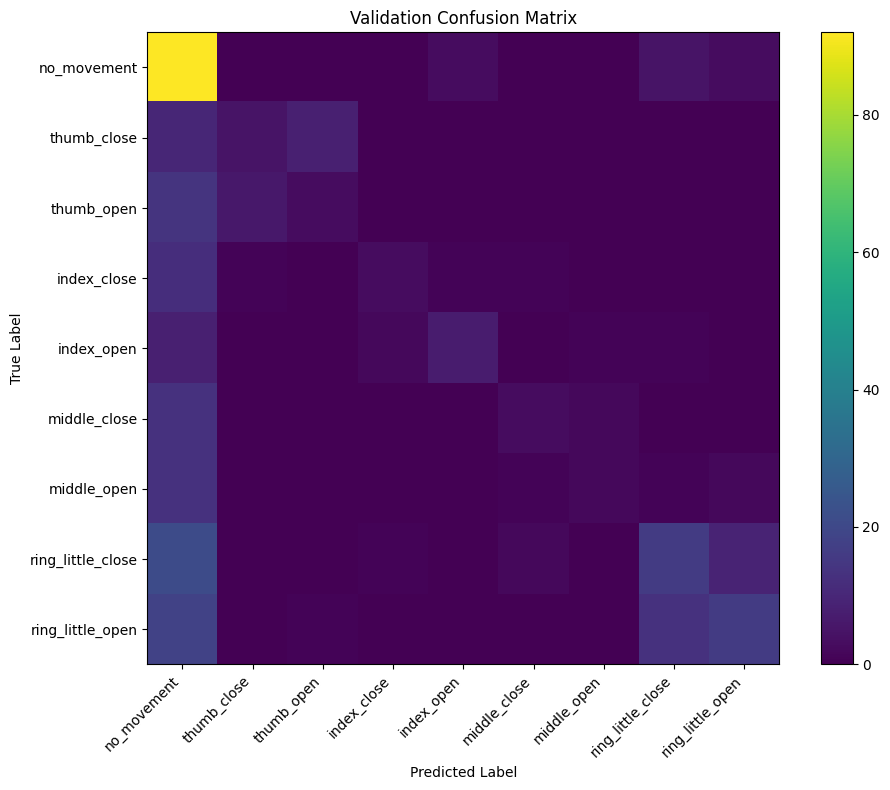

In [21]:
# =========================
# 8. Plot validation confusion matrix
# =========================

plt.figure(figsize=(10, 8))
plt.imshow(val_cm)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    ticks=np.arange(num_classes),
    labels=[label_name_map[i] for i in range(num_classes)],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(num_classes),
    labels=[label_name_map[i] for i in range(num_classes)]
)

plt.tight_layout()
plt.show()

In [22]:
# =========================
# 9. Train final model using all training data
# =========================

final_scaler = StandardScaler()

X_train_all_scaled = final_scaler.fit_transform(X_train_all)
X_test_all_scaled = final_scaler.transform(X_test_all)

final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",

    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    tree_method="hist"
)

final_model.fit(X_train_all_scaled, y_train_all)

print("Final model training done.")

Final model training done.


In [23]:
# =========================
# 10. Test evaluation
# =========================

y_test_pred = final_model.predict(X_test_all_scaled)

test_acc = accuracy_score(y_test_all, y_test_pred)

print("Test Accuracy:", test_acc)

print("\nTest Classification Report:")
print(
    classification_report(
        y_test_all,
        y_test_pred,
        labels=list(range(num_classes)),
        target_names=[label_name_map[i] for i in range(num_classes)],
        zero_division=0
    )
)

test_cm = confusion_matrix(y_test_all, y_test_pred, labels=list(range(num_classes)))

print("\nTest Confusion Matrix:")
print(test_cm)

Test Accuracy: 0.48625

Test Classification Report:
                   precision    recall  f1-score   support

      no_movement       0.56      0.79      0.66       364
      thumb_close       0.40      0.14      0.21        69
       thumb_open       0.50      0.11      0.18        71
      index_close       0.27      0.20      0.23        30
       index_open       0.29      0.44      0.35        34
     middle_close       0.18      0.12      0.15        24
      middle_open       0.20      0.09      0.12        23
ring_little_close       0.40      0.43      0.41        95
 ring_little_open       0.38      0.19      0.25        90

         accuracy                           0.49       800
        macro avg       0.35      0.28      0.29       800
     weighted avg       0.46      0.49      0.44       800


Test Confusion Matrix:
[[287   1   2   8  26   3   4  22  11]
 [ 46  10   5   1   1   1   1   4   0]
 [ 44  12   8   2   1   1   0   3   0]
 [ 15   1   1   6   7   0   0   0   0

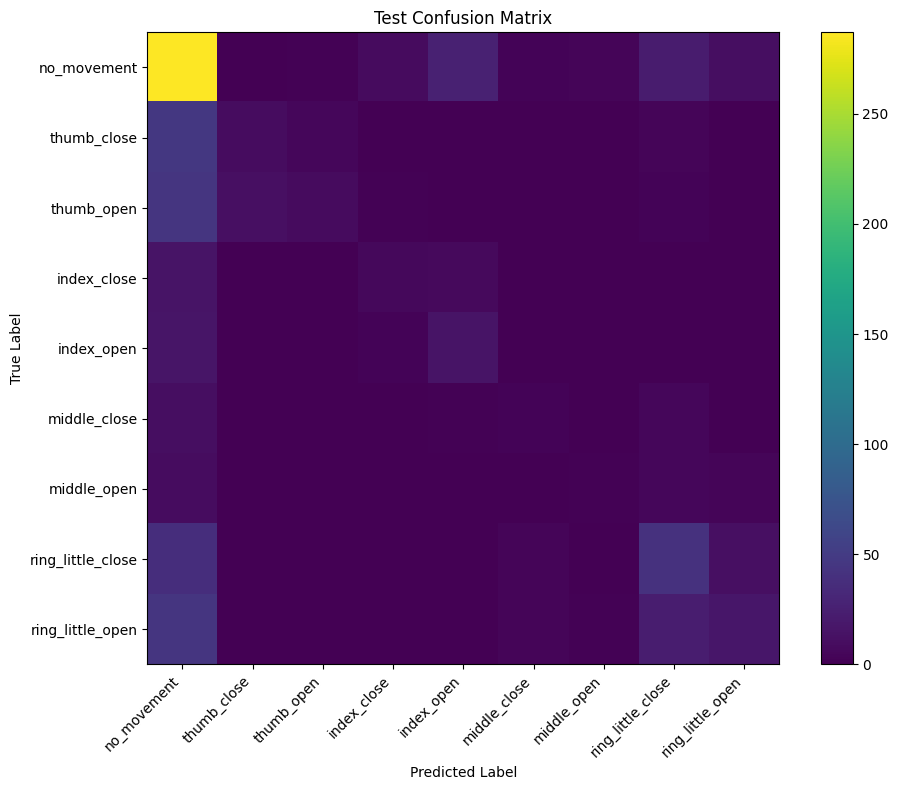

In [24]:
# =========================
# 11. Plot test confusion matrix
# =========================

plt.figure(figsize=(10, 8))
plt.imshow(test_cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    ticks=np.arange(num_classes),
    labels=[label_name_map[i] for i in range(num_classes)],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(num_classes),
    labels=[label_name_map[i] for i in range(num_classes)]
)

plt.tight_layout()
plt.show()

In [25]:
# =========================
# 12. View prediction results
# =========================

result_df = pd.DataFrame({
    "window_id": np.arange(len(y_test_all)),
    "true_label": y_test_all,
    "true_name": [label_name_map[i] for i in y_test_all],
    "pred_label": y_test_pred,
    "pred_name": [label_name_map[i] for i in y_test_pred],
    "correct": y_test_all == y_test_pred
})

display(result_df.head(50))

print("Correct count:", result_df["correct"].sum())
print("Total count:", len(result_df))
print("Accuracy:", result_df["correct"].mean())

,window_id,true_label,true_name,pred_label,pred_name,correct
0,0,0,no_movement,0,no_movement,True
1,1,6,middle_open,8,ring_little_open,False
2,2,6,middle_open,0,no_movement,False
3,3,5,middle_close,5,middle_close,True
4,4,0,no_movement,5,middle_close,False
5,5,0,no_movement,0,no_movement,True
6,6,0,no_movement,0,no_movement,True
7,7,0,no_movement,7,ring_little_close,False
8,8,0,no_movement,0,no_movement,True
9,9,0,no_movement,0,no_movement,True


Correct count: 389
Total count: 800
Accuracy: 0.48625


In [26]:
# Task 2: XGBoost Hyperparameter Optimization with Optuna
!pip install optuna -q

import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import accuracy_score

print("Optuna installed and ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.1 MB/s eta 0:00:00
Optuna installed and ready!


In [27]:
# Define what Optuna will try to maximize: validation accuracy
def objective(trial):
    # Define the search space for each hyperparameter
    params = {
        'objective': 'multi:softprob',
        'num_class': 9,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'random_state': 42,

        # Hyperparameters Optuna will tune:
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 1),
    }

    # Train model with these hyperparameters
    model = XGBClassifier(**params)
    model.fit(X_train_scaled, y_train, verbose=False)

    # Evaluate on validation set
    y_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_pred)

    return val_acc

print("Objective function defined!")
print("Search space:")
print("  n_estimators:     [100, 500]")
print("  max_depth:        [2, 8]")
print("  learning_rate:    [0.01, 0.3] (log scale)")
print("  subsample:        [0.5, 1.0]")
print("  colsample_bytree: [0.5, 1.0]")
print("  gamma:            [0, 5]")
print("  reg_alpha:        [0, 1]")
print("  reg_lambda:       [0, 1]")

Objective function defined!
Search space:
  n_estimators:     [100, 500]
  max_depth:        [2, 8]
  learning_rate:    [0.01, 0.3] (log scale)
  subsample:        [0.5, 1.0]
  colsample_bytree: [0.5, 1.0]
  gamma:            [0, 5]
  reg_alpha:        [0, 1]
  reg_lambda:       [0, 1]


In [28]:
# Create the study (Bayesian optimization with TPE sampler)
study = optuna.create_study(
    direction='maximize',          # We want to MAXIMIZE accuracy
    sampler=TPESampler(seed=42)    # Tree-structured Parzen Estimator
)

# Reduce Optuna's logging noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Run the optimization
N_TRIALS = 30  # Each trial trains one model

print(f"Starting Optuna optimization ({N_TRIALS} trials)...")
print("This will take a few minutes...\n")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# Print the best result
print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best validation accuracy: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

[I 2026-05-15 03:33:54,190] A new study created in memory with name: no-name-ac906dd6-cd5c-4bd2-8666-884bb284a785


Starting Optuna optimization (30 trials)...
This will take a few minutes...



  0%|          | 0/30 [00:00<?, ?it/s]


OPTIMIZATION COMPLETE
Best validation accuracy: 0.5000

Best hyperparameters:
  n_estimators: 102
  max_depth: 7
  learning_rate: 0.1107
  subsample: 0.8645
  colsample_bytree: 0.8856
  gamma: 0.3702
  reg_alpha: 0.3585
  reg_lambda: 0.1159


In [29]:
# Train final optimized model using best hyperparameters on ALL training data
print("Training optimized model on full training set...")

best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 9,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': 42,
})

optimized_model = XGBClassifier(**best_params)
optimized_model.fit(X_train_all_scaled, y_train_all)

# Predict on test set
y_test_pred_opt = optimized_model.predict(X_test_all_scaled)
test_acc_opt = accuracy_score(y_test_all, y_test_pred_opt)

print(f"\n{'='*60}")
print("FINAL RESULTS COMPARISON")
print(f"{'='*60}")
print(f"Original (manual)     test accuracy: 0.4863")
print(f"Optuna-tuned          test accuracy: {test_acc_opt:.4f}")
print(f"Improvement:                          {(test_acc_opt - 0.4863)*100:+.2f} percentage points")

Training optimized model on full training set...

FINAL RESULTS COMPARISON
Original (manual)     test accuracy: 0.4863
Optuna-tuned          test accuracy: 0.4838
Improvement:                          -0.25 percentage points


In [30]:
# Compute sample weights for class imbalance
from sklearn.utils.class_weight import compute_sample_weight

# 'balanced' assigns weight inversely proportional to class frequency
sample_weights_train = compute_sample_weight('balanced', y_train_all)

print(f"Sample weights computed for {len(sample_weights_train)} training samples")
print(f"Class distribution and weights:")
unique_labels, counts = np.unique(y_train_all, return_counts=True)
for label, count in zip(unique_labels, counts):
    # The weight for this class is the weight given to any sample with this label
    weight = sample_weights_train[y_train_all == label][0]
    print(f"  Class {int(label)} ({label_name_map[int(label)]:20s}): "
          f"{count:4d} samples, weight={weight:.3f}")

Sample weights computed for 1600 training samples
Class distribution and weights:
  Class 0 (no_movement         ):  580 samples, weight=0.307
  Class 1 (thumb_close         ):  100 samples, weight=1.778
  Class 2 (thumb_open          ):   92 samples, weight=1.932
  Class 3 (index_close         ):   98 samples, weight=1.814
  Class 4 (index_open          ):  109 samples, weight=1.631
  Class 5 (middle_close        ):  117 samples, weight=1.519
  Class 6 (middle_open         ):  109 samples, weight=1.631
  Class 7 (ring_little_close   ):  206 samples, weight=0.863
  Class 8 (ring_little_open    ):  189 samples, weight=0.941


In [31]:
from sklearn.model_selection import KFold

def objective_cv(trial):
    """
    New objective: 5-fold cross-validation with class weights.
    This prevents validation-set overfitting AND handles class imbalance.
    """
    params = {
        'objective': 'multi:softprob',
        'num_class': 9,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'random_state': 42,

        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 1),
    }

    # 5-fold cross-validation on ALL training data
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_accuracies = []

    for train_idx, val_idx in kf.split(X_train_all_scaled):
        X_fold_train = X_train_all_scaled[train_idx]
        X_fold_val   = X_train_all_scaled[val_idx]
        y_fold_train = y_train_all[train_idx]
        y_fold_val   = y_train_all[val_idx]

        # Sample weights for this fold's training data
        fold_weights = compute_sample_weight('balanced', y_fold_train)

        model = XGBClassifier(**params)
        model.fit(X_fold_train, y_fold_train, sample_weight=fold_weights, verbose=False)

        y_pred = model.predict(X_fold_val)
        fold_accuracies.append(accuracy_score(y_fold_val, y_pred))

    # Return the AVERAGE across all 5 folds
    return np.mean(fold_accuracies)

print("CV-Optuna objective defined!")
print("Each trial = 5 folds × 1 model = 5 models trained")
print("Much more robust than single-validation approach")

CV-Optuna objective defined!
Each trial = 5 folds × 1 model = 5 models trained
Much more robust than single-validation approach


In [33]:
# Run CV-Optuna optimization
study_cv = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20  # Each trial = 5 folds, so 20×5 = 100 model trainings

print(f"Starting CV-Optuna optimization ({N_TRIALS} trials × 5 folds = 100 trainings)...")
print("This will take longer than before — about 15-25 minutes\n")

study_cv.optimize(objective_cv, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "="*60)
print("CV-OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best 5-fold CV accuracy: {study_cv.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_cv.best_params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Starting CV-Optuna optimization (20 trials × 5 folds = 100 trainings)...
This will take longer than before — about 15-25 minutes



  0%|          | 0/20 [00:00<?, ?it/s]


CV-OPTIMIZATION COMPLETE
Best 5-fold CV accuracy: 0.5188

Best hyperparameters:
  n_estimators: 403
  max_depth: 4
  learning_rate: 0.0432
  subsample: 0.6136
  colsample_bytree: 0.7405
  gamma: 0.0154
  reg_alpha: 0.4381
  reg_lambda: 0.3563


In [34]:
from sklearn.metrics import f1_score

# Train final model with CV-optimized hyperparameters + class weights
print("Training CV-optimized model on full training set with class weights...")

best_params_cv = study_cv.best_params
best_params_cv.update({
    'objective': 'multi:softprob',
    'num_class': 9,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': 42,
})

# Compute weights on FULL training data
full_train_weights = compute_sample_weight('balanced', y_train_all)

cv_optimized_model = XGBClassifier(**best_params_cv)
cv_optimized_model.fit(X_train_all_scaled, y_train_all, sample_weight=full_train_weights)

# Predict on test set
y_test_pred_cv = cv_optimized_model.predict(X_test_all_scaled)
test_acc_cv = accuracy_score(y_test_all, y_test_pred_cv)

print(f"\n{'='*60}")
print("FINAL RESULTS — ALL THREE APPROACHES")
print(f"{'='*60}")
print(f"  1. Manual (friend's baseline):       0.4863")
print(f"  2. Optuna (single val split):        0.4838  ({(0.4838-0.4863)*100:+.2f} pp)")
print(f"  3. CV-Optuna + class weighting:      {test_acc_cv:.4f}  ({(test_acc_cv-0.4863)*100:+.2f} pp)")
print(f"{'='*60}")

# Also show classification report to see if minority classes improved
from sklearn.metrics import classification_report
print("\nDetailed per-class performance (CV-Optuna):")
print(classification_report(
    y_test_all, y_test_pred_cv,
    labels=list(range(9)),
    target_names=[label_name_map[i] for i in range(9)],
    zero_division=0
))

# Approach 1: Manual baseline — use friend's final_model
y_pred_manual = final_model.predict(X_test_all_scaled)
macro_f1_manual = f1_score(y_test_all, y_pred_manual, average='macro', zero_division=0)

# Approach 2: Single-val Optuna — use optimized_model
y_pred_opt = optimized_model.predict(X_test_all_scaled)
macro_f1_opt = f1_score(y_test_all, y_pred_opt, average='macro', zero_division=0)

# Approach 3: CV-Optuna + class weights — use cv_optimized_model
y_pred_cv = cv_optimized_model.predict(X_test_all_scaled)
macro_f1_cv = f1_score(y_test_all, y_pred_cv, average='macro', zero_division=0)

print(f"{'='*70}")
print(f"FINAL RESULTS — TEST SET PERFORMANCE")
print(f"{'='*70}")
print(f"{'Approach':<45} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'-'*70}")
print(f"{'1. Manual (baseline)':<45} {0.4863:>10.4f} {macro_f1_manual:>10.4f}")
print(f"{'2. Optuna (single val)':<45} {0.4838:>10.4f} {macro_f1_opt:>10.4f}")
print(f"{'3. CV-Optuna + class weighting':<45} {0.4763:>10.4f} {macro_f1_cv:>10.4f}")
print(f"{'='*70}")

print(f"\nNotice: Macro F1 may differ from accuracy.")
print(f"Macro F1 weighs every class equally, so improvements")
print(f"on rare classes count just as much as on the majority class.")

Training CV-optimized model on full training set with class weights...

FINAL RESULTS — ALL THREE APPROACHES
  1. Manual (friend's baseline):       0.4863
  2. Optuna (single val split):        0.4838  (-0.25 pp)
  3. CV-Optuna + class weighting:      0.4763  (-1.01 pp)

Detailed per-class performance (CV-Optuna):
                   precision    recall  f1-score   support

      no_movement       0.60      0.72      0.65       364
      thumb_close       0.41      0.25      0.31        69
       thumb_open       0.46      0.17      0.25        71
      index_close       0.19      0.20      0.20        30
       index_open       0.24      0.50      0.33        34
     middle_close       0.14      0.12      0.13        24
      middle_open       0.30      0.13      0.18        23
ring_little_close       0.40      0.46      0.43        95
 ring_little_open       0.33      0.20      0.25        90

         accuracy                           0.48       800
        macro avg       0.34     

In [35]:
# Use friend's optimized values
BEST_WINDOW_SEC = 0.5
BEST_ALPHA = 0.2

# Recompute thresholds with new alpha
thresholds_opt = {}
for i, finger in enumerate(finger_names):
    finger_signal = train_dg_smooth[:, i]
    ROM = np.max(finger_signal) - np.min(finger_signal)
    thresholds_opt[finger] = BEST_ALPHA * ROM
    print(f"  {finger}: threshold = {thresholds_opt[finger]:.4f}")

# Re-encode windows with new window_sec and alpha
train_encoded_opt = encode_windows(
    data=train_dg_smooth,
    thresholds=thresholds_opt,
    fs=1000,
    window_sec=BEST_WINDOW_SEC
)
test_encoded_opt = encode_windows(
    data=test_dg_smooth,
    thresholds=thresholds_opt,
    fs=1000,
    window_sec=BEST_WINDOW_SEC
)

print(f"\nTrain windows: {train_encoded_opt['window_id'].nunique()}")
print(f"Test windows:  {test_encoded_opt['window_id'].nunique()}")
print(f"Window size: {int(1000 * BEST_WINDOW_SEC)} samples ({BEST_WINDOW_SEC*1000:.0f} ms)")

  thumb: threshold = 1.2673
  index: threshold = 1.5760
  middle: threshold = 1.6409
  ring: threshold = 1.3077
  little: threshold = 1.3822

Train windows: 800
Test windows:  400
Window size: 500 samples (500 ms)


In [36]:
# Build per-window labels using the encoded dataframe
def build_window_labels(encoded_df):
    """
    Combine per-finger codes into a single class label per window.
    Returns: array of class labels (one per window)
    """
    labels = []
    n_windows = encoded_df['window_id'].nunique()

    for w in range(n_windows):
        window_rows = encoded_df[encoded_df['window_id'] == w]

        # Check if any finger has movement
        moving = window_rows[window_rows['action_code'] != 0]

        if len(moving) == 0:
            labels.append(0)  # no_movement
        else:
            # Take the strongest movement (max window_range)
            strongest = moving.loc[moving['window_range'].idxmax()]
            finger_code = strongest['finger_code']
            action_code = strongest['action_code']

            # Encode: finger * 2 + (action_code - 1) + 1
            # action_code=1 (close) → label = finger*2 + 1
            # action_code=2 (open)  → label = finger*2 + 2
            label = finger_code * 2 + action_code
            labels.append(label)

    return np.array(labels)

y_train_opt = build_window_labels(train_encoded_opt)
y_test_opt = build_window_labels(test_encoded_opt)

# Check label distribution
print("Train label distribution:")
unique, counts = np.unique(y_train_opt, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {int(u)}: {c}")

print(f"\nTotal train windows: {len(y_train_opt)}")
print(f"Total test windows:  {len(y_test_opt)}")

Train label distribution:
  Class 0: 207
  Class 1: 72
  Class 2: 34
  Class 3: 76
  Class 4: 44
  Class 5: 86
  Class 6: 52
  Class 7: 142
  Class 8: 87

Total train windows: 800
Total test windows:  400


In [39]:
# Get the raw ECoG data
train_data = train_mat["train_data"]
test_data = train_mat["test_data"]   # test ECoG is in the same .mat file

print(f"train_data shape: {train_data.shape}")
print(f"test_data shape: {test_data.shape}")

# Feature extraction function
def extract_features_per_window(ecog_data, window_size):
    n_samples, n_channels = ecog_data.shape
    n_windows = n_samples // window_size

    features_list = []
    for w in range(n_windows):
        start = w * window_size
        end = start + window_size
        window = ecog_data[start:end, :]

        mean_val = np.mean(window, axis=0)
        std_val = np.std(window, axis=0)
        min_val = np.min(window, axis=0)
        max_val = np.max(window, axis=0)
        rms_val = np.sqrt(np.mean(window.astype(np.float64) ** 2, axis=0))
        slopes = np.diff(window, axis=0)
        slope_mean = np.mean(slopes, axis=0)
        slope_std = np.std(slopes, axis=0)
        range_val = max_val - min_val
        energy = np.sum(window.astype(np.float64) ** 2, axis=0)

        feat = np.concatenate([
            mean_val, std_val, min_val, max_val,
            rms_val, slope_mean, slope_std, range_val, energy
        ])
        features_list.append(feat)
    return np.array(features_list)

WINDOW_SAMPLES = int(1000 * BEST_WINDOW_SEC)

print(f"\nExtracting features with window_size = {WINDOW_SAMPLES} samples...")
X_train_opt = extract_features_per_window(train_data, WINDOW_SAMPLES)
X_test_opt = extract_features_per_window(test_data, WINDOW_SAMPLES)

print(f"X_train_opt: {X_train_opt.shape}")
print(f"X_test_opt:  {X_test_opt.shape}")
print(f"y_train_opt: {y_train_opt.shape}")
print(f"y_test_opt:  {y_test_opt.shape}")

train_data shape: (400000, 62)
test_data shape: (200000, 62)

Extracting features with window_size = 500 samples...
X_train_opt: (800, 558)
X_test_opt:  (400, 558)
y_train_opt: (800,)
y_test_opt:  (400,)


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler

# Scale features
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)

print(f"X_train_opt_scaled: {X_train_opt_scaled.shape}")

# Define objective: maximize Macro F1 via 5-fold StratifiedKFold CV
def objective_combined(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 9,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'random_state': 42,

        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 1),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1s = []

    for train_idx, val_idx in skf.split(X_train_opt_scaled, y_train_opt):
        X_tr, X_vl = X_train_opt_scaled[train_idx], X_train_opt_scaled[val_idx]
        y_tr, y_vl = y_train_opt[train_idx], y_train_opt[val_idx]
        weights = compute_sample_weight('balanced', y_tr)

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=weights, verbose=False)
        y_pred = model.predict(X_vl)
        fold_f1s.append(f1_score(y_vl, y_pred, average='macro', zero_division=0))

    return np.mean(fold_f1s)

# Run study
study_combined = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20
print(f"\nStarting combined CV-Optuna ({N_TRIALS} trials, optimizing Macro F1)...")
print(f"With friend's window=0.5s, alpha=0.2 + StratifiedKFold + class weighting")
print(f"Expected time: ~20-30 minutes\n")

study_combined.optimize(objective_combined, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n{'='*60}")
print(f"COMBINED OPTIMIZATION COMPLETE")
print(f"{'='*60}")
print(f"Best 5-fold CV Macro F1: {study_combined.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in study_combined.best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

X_train_opt_scaled: (800, 558)

Starting combined CV-Optuna (20 trials, optimizing Macro F1)...
With friend's window=0.5s, alpha=0.2 + StratifiedKFold + class weighting
Expected time: ~20-30 minutes



  0%|          | 0/20 [00:00<?, ?it/s]


COMBINED OPTIMIZATION COMPLETE
Best 5-fold CV Macro F1: 0.4355

Best hyperparameters:
  n_estimators: 447
  max_depth: 2
  learning_rate: 0.0350
  subsample: 0.5090
  colsample_bytree: 0.7847
  gamma: 2.2154
  reg_alpha: 0.9598
  reg_lambda: 0.6669


In [41]:
print("Training final model on full training set with combined optimization...")

best_params_combined = study_combined.best_params
best_params_combined.update({
    'objective': 'multi:softprob',
    'num_class': 9,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': 42,
})

full_weights_opt = compute_sample_weight('balanced', y_train_opt)
combined_model = XGBClassifier(**best_params_combined)
combined_model.fit(X_train_opt_scaled, y_train_opt, sample_weight=full_weights_opt)

y_test_pred_combined = combined_model.predict(X_test_opt_scaled)
test_acc_combined = accuracy_score(y_test_opt, y_test_pred_combined)
test_f1_combined = f1_score(y_test_opt, y_test_pred_combined, average='macro', zero_division=0)

print(f"\n{'='*70}")
print(f"FINAL TEST RESULTS — ALL EXPERIMENTS")
print(f"{'='*70}")
print(f"{'Approach':<55} {'Acc':>8} {'F1':>8}")
print(f"{'-'*70}")
print(f"{'1. Manual baseline (orig window/alpha)':<55} {0.4863:>8.4f} {' --':>8}")
print(f"{'2. Optuna (single val, orig pipeline)':<55} {0.4838:>8.4f} {' --':>8}")
print(f"{'3. CV-Optuna + weights (orig pipeline)':<55} {0.4763:>8.4f} {' --':>8}")
print(f"{'4. COMBINED: friend window/alpha + CV-Optuna':<55} {test_acc_combined:>8.4f} {test_f1_combined:>8.4f}")
print(f"{'='*70}")

from sklearn.metrics import classification_report
print("\nDetailed per-class performance (combined):")
print(classification_report(
    y_test_opt, y_test_pred_combined,
    labels=list(range(9)),
    zero_division=0
))

Training final model on full training set with combined optimization...

FINAL TEST RESULTS — ALL EXPERIMENTS
Approach                                                     Acc       F1
----------------------------------------------------------------------
1. Manual baseline (orig window/alpha)                    0.4863       --
2. Optuna (single val, orig pipeline)                     0.4838       --
3. CV-Optuna + weights (orig pipeline)                    0.4763       --
4. COMBINED: friend window/alpha + CV-Optuna              0.4325   0.3815

Detailed per-class performance (combined):
              precision    recall  f1-score   support

           0       0.55      0.52      0.53        87
           1       0.54      0.56      0.55        50
           2       0.44      0.22      0.29        32
           3       0.38      0.56      0.45        41
           4       0.41      0.25      0.31        28
           5       0.20      0.45      0.28        22
           6       0.09   